# Dynamical Modeling

Here, we use the generalized dynamical model to solve the full transcriptional dynamics. 

That yields several additional insights such as latent time and identification of putative driver genes.

As in the previous tutorial, it is illustratively applied to endocrine development in the [pancreas](https://scvelo.readthedocs.io/scvelo.datasets.pancreas).

In [1]:
# update to the latest version, if not done yet.
# !pip install scvelo --upgrade --quiet

In [2]:
import scvelo as scv
import pandas as pd
import numpy as np
import matplotlib as plt
import anndata
plt.rcParams['figure.figsize'] = (6, 6)

In [3]:
scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
scv.settings.presenter_view = True  # set max width size for presenter view
scv.settings.set_figure_params('scvelo')  # for beautified visualization

### Load and Add metadata and reduction to Anndata
Processing consists of gene selection, normalizing by total size, logarithmizing X, and computing moments for velocity estimation. See the previous tutorial for further explanation.

In [ ]:
adata_obs = pd.read_csv("cellID_obs.csv")
umap = pd.read_csv("cell_embeddings_umap.csv")
cell_clusters = pd.read_csv("clusters.csv")
adata = anndata.read_h5ad("../../../../CellRanger/Velocyto.h5ad")
adata

In [ ]:
# Only keep cells from seurat object
adata = adata[np.isin(adata.obs.index,adata_obs["x"])]
adata
# order cells from umap coordinate
adata_index = pd.DataFrame(adata.obs.index)
adata_index = adata_index.rename(columns = {0:'CellID'})
umap = umap.rename(columns = {'Unnamed: 0':'CellID'})
umap_ordered = adata_index.merge(umap,on="CellID")
# Add umap coordinate to Anndata object
umap_ordered = umap_ordered.iloc[:,1:]
adata.obsm['X_umap'] = umap_ordered.values
# reorder cell_cluster
cell_clusters = cell_clusters.rename(columns = {'cells':'CellID'})
clusters_ordered = adata_index.merge(cell_clusters,on="CellID")
# Add cluster info to Anndata object
# adata.obs['clusters'] dtype category must be string, not int
adata.obs['clusters'] = clusters_ordered['RNA_snn_res.0.2'].astype(str).astype('category').values

In [6]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 24997 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_38080/3334712381.py:2: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since 

computing neighbors
    finished (0:00:05) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


### Dynamical Model

We run the dynamical model to learn the full transcriptional dynamics of splicing kinetics. 

It is solved in a likelihood-based expectation-maximization framework, by iteratively estimating the
parameters of reaction rates and latent cell-specific variables, i.e. transcriptional state and cell-internal latent time. It thereby aims to learn the unspliced/spliced phase trajectory for each gene.

In [7]:
scv.tl.recover_dynamics(adata, n_jobs = 24)

recovering dynamics (using 24/48 cores)


  0%|          | 0/1461 [00:00<?, ?gene/s]

    finished (0:00:36) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [8]:
scv.tl.velocity(adata, mode='dynamical')
scv.tl.velocity_graph(adata, n_jobs = 24)

computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 24/48 cores)


  0%|          | 0/2528 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


Running the dynamical model can take a while. Hence, you may want to store the results for re-use, with `adata.write('data/pancreas.h5ad'`, which can later be read with `adata = scv.read('data/pancreas.h5ad')`.

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/minicon

saving figure to file ./figures/pl.velocity_embedding_stream_umap_dymamical.svg


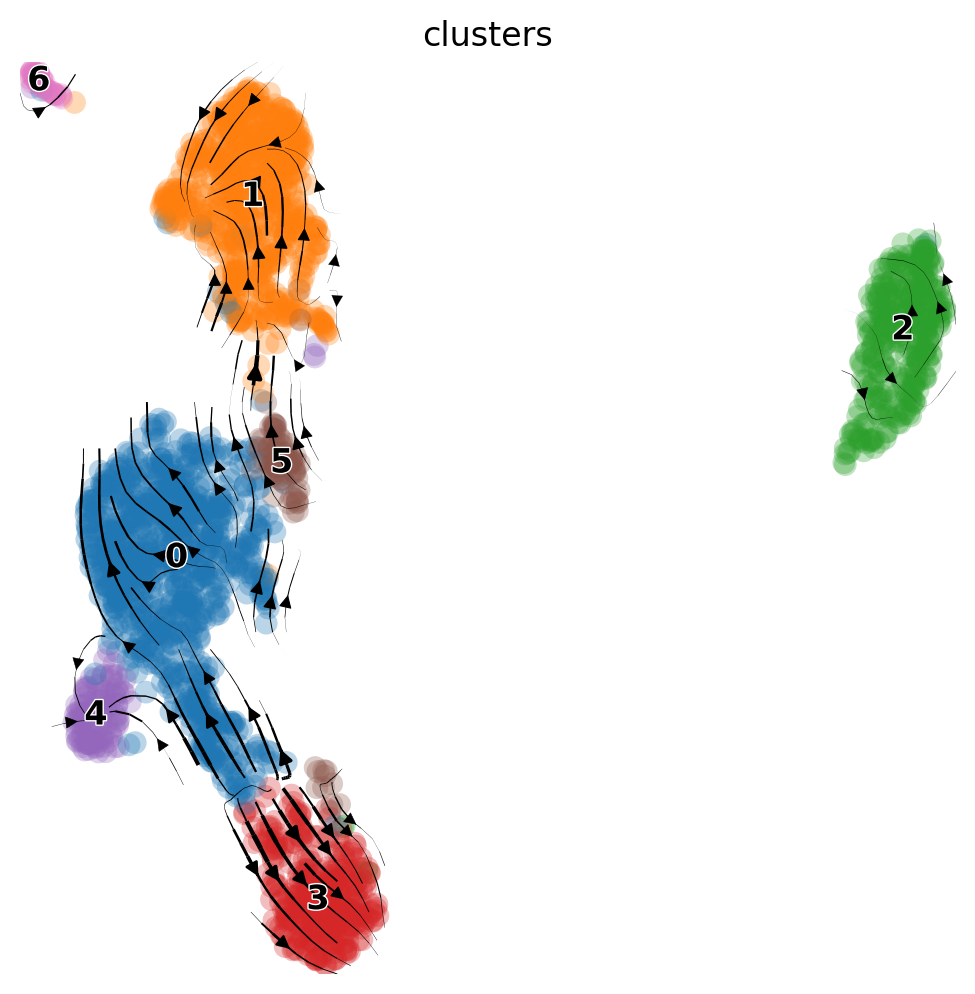

In [9]:
scv.pl.velocity_embedding_stream(adata, basis='umap', figsize = (6,6),save = "./figures/pl.velocity_embedding_stream_umap_dymamical.svg")

### Kinetic rate paramters

The rates of RNA transcription, splicing and degradation are estimated without the need of any experimental data.

They can be useful to better understand the cell identity and phenotypic heterogeneity.

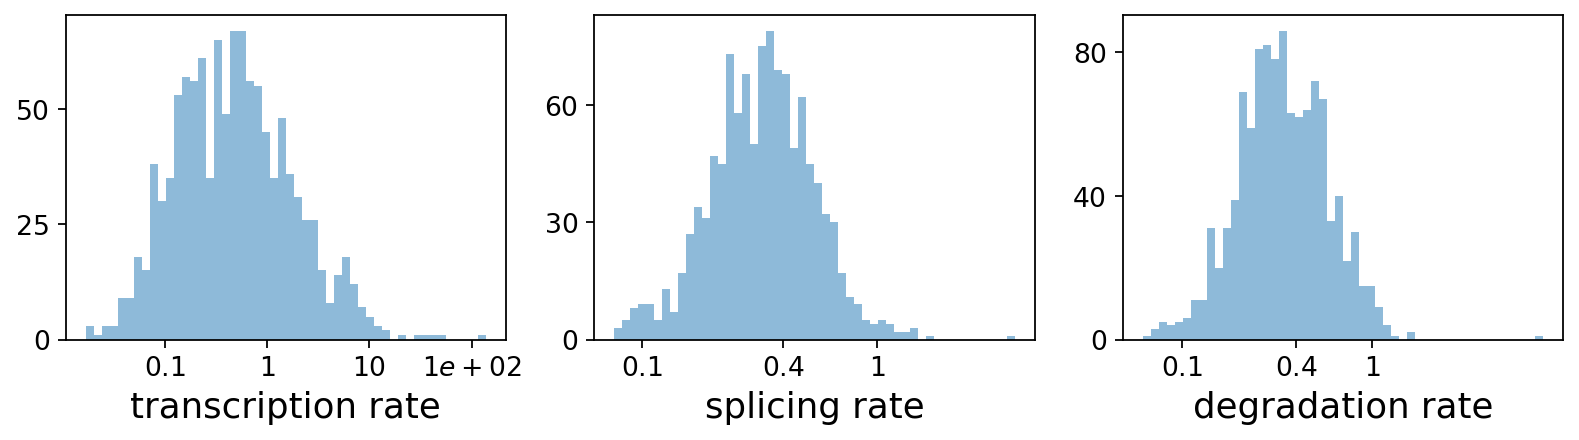

/tmp/ipykernel_38080/592125562.py:10: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  scv.get_df(adata, 'fit*', dropna=True).head(10)


,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
Sntg1,0.605513,0.040526,0.002645,0.112426,21.367901,79.952468,4.900044,0.069118,0.309283,0.0,0.0,0.182952,11.324039,0.187916,0.564262,5.600409
Prex2,0.077905,0.252039,0.082731,0.206549,9.460026,6.206622,0.937227,0.203856,0.314706,0.0,0.0,0.260873,2.148621,0.570125,0.576410,2.629120
Sulf1,0.895065,1.194573,0.180597,0.413466,6.821449,1.339136,1.449294,0.503251,0.336371,0.0,0.0,0.485208,5.290153,1.804989,0.378322,1.767671
Eya1,0.395465,0.039600,0.050891,0.120990,20.947815,5.228818,0.262211,0.063478,0.261099,0.0,0.0,0.109576,0.671465,0.182203,0.808135,4.757002
Msc,0.313097,1.873222,5.492106,0.469421,6.977861,0.050494,0.089845,0.840735,0.269689,0.0,0.0,0.490764,0.277156,3.241411,0.611785,1.622697
Rdh10,0.892579,2.851609,1.581159,0.528368,11.054962,0.171586,0.589645,1.623716,0.460926,0.0,0.0,0.490246,1.667697,3.676793,0.260785,1.658649
Stau2,0.823532,0.111334,0.028767,0.138642,20.034065,3.321742,1.073548,0.150283,0.307363,0.0,0.0,0.411503,2.630600,0.431363,0.499413,4.697406
Pi15,0.546449,0.663027,1.366729,0.382879,8.928827,0.534179,0.164623,0.415273,0.265416,0.0,0.0,0.339967,0.450351,1.208716,0.767650,1.669914
Gsta3,0.700828,1.342138,1.696453,0.517293,6.829949,0.190698,0.277187,0.686795,0.329039,0.0,0.0,0.429914,0.695327,1.595290,0.478735,1.390990
Gm4956,0.761658,0.480633,0.864936,0.869030,5.678131,0.409472,0.084344,0.097327,0.013481,0.0,0.0,0.477988,0.253058,0.424313,0.201961,1.238824


In [10]:
df = adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]

kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)    
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)
    
scv.get_df(adata, 'fit*', dropna=True).head(10)


The estimated gene-specific parameters comprise rates of transription (`fit_alpha`), splicing (`fit_beta`), degradation (`fit_gamma`), switching time point (`fit_t_`), a scaling parameter to adjust for under-represented unspliced reads (`fit_scaling`), standard deviation of unspliced and spliced reads (`fit_std_u`, `fit_std_s`), the gene likelihood (`fit_likelihood`), inferred steady-state levels (`fit_steady_u`, `fit_steady_s`) with their corresponding p-values (`fit_pval_steady_u`, `fit_pval_steady_s`), the overall model variance (`fit_variance`), and a scaling factor to align the gene-wise latent times to a universal, gene-shared latent time (`fit_alignment_scaling`).

### Latent time

The dynamical model recovers the latent time of the underlying cellular processes. This latent time represents the cell’s internal clock and approximates the real time experienced by cells as they differentiate, based only on its transcriptional dynamics. 

computing terminal states
    identified 3 regions of root cells and 2 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:00) --> added 
    'latent_time', shared time (adata.obs)


/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/minicon

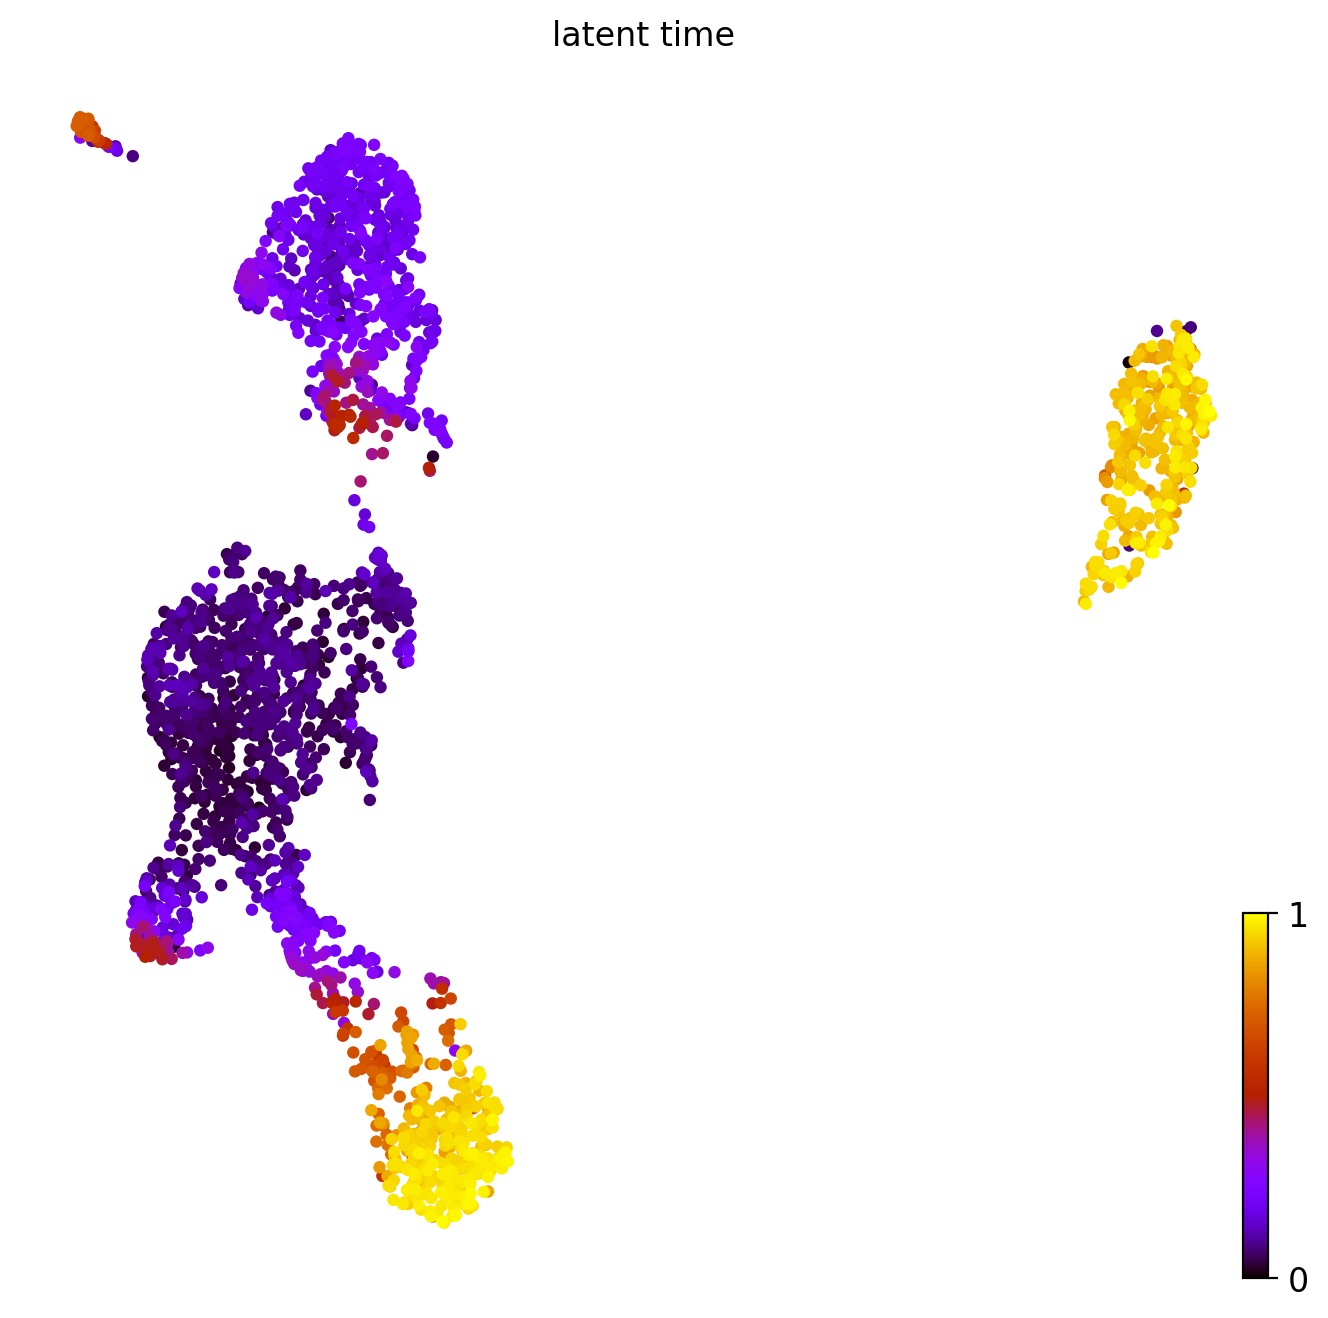

In [11]:
scv.tl.latent_time(adata)
scv.pl.scatter(adata, color='latent_time', color_map='gnuplot', size=80, figsize=(8,8))

/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


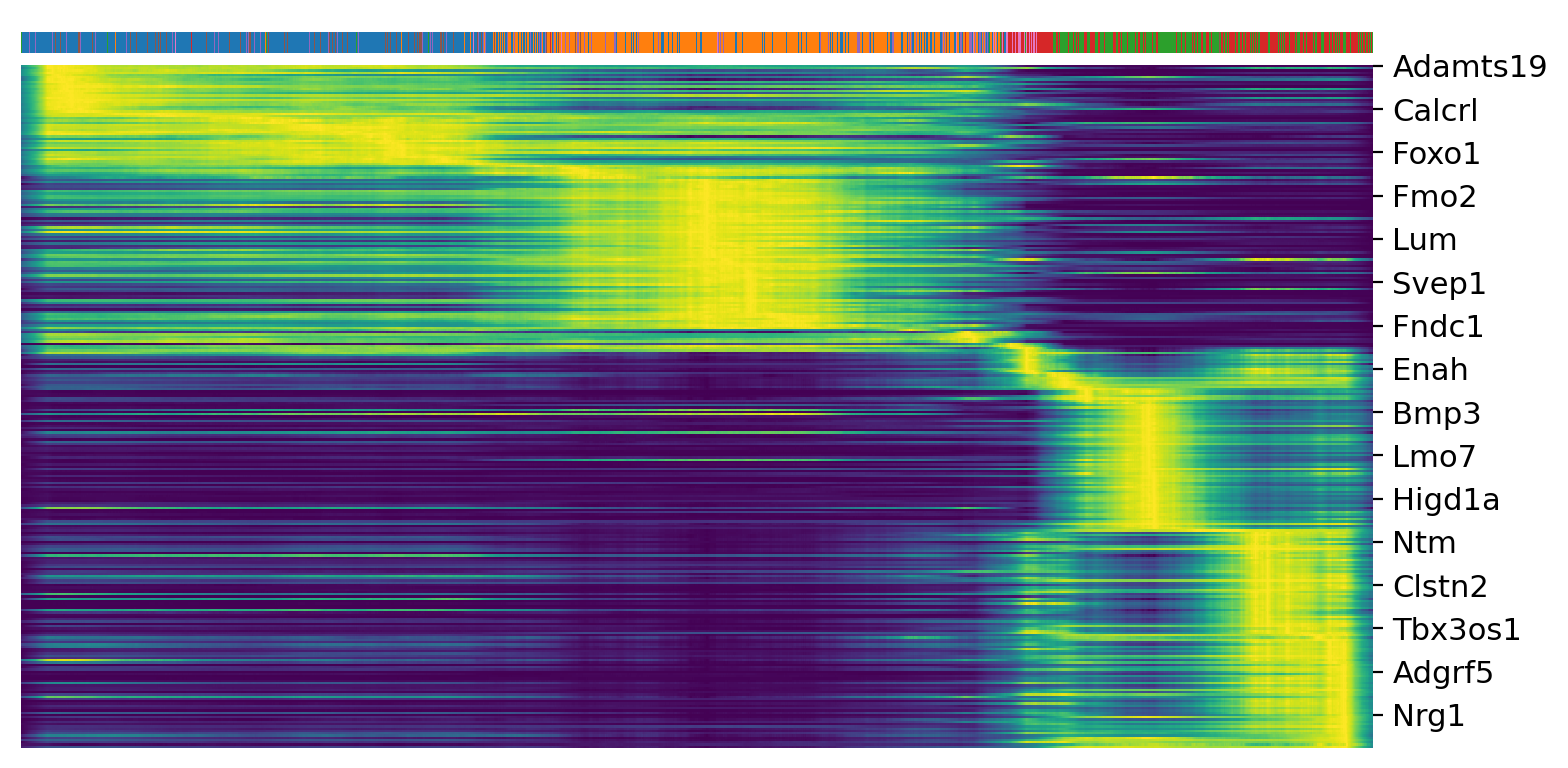

In [12]:
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index[:300]
scv.pl.heatmap(adata, var_names=top_genes, sortby='latent_time', col_color='clusters', n_convolve=100)

### Top-likelihood genes

Driver genes display pronounced dynamic behavior and are systematically detected via their characterization by high likelihoods in the dynamic model. 

/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xilab/software/minicon

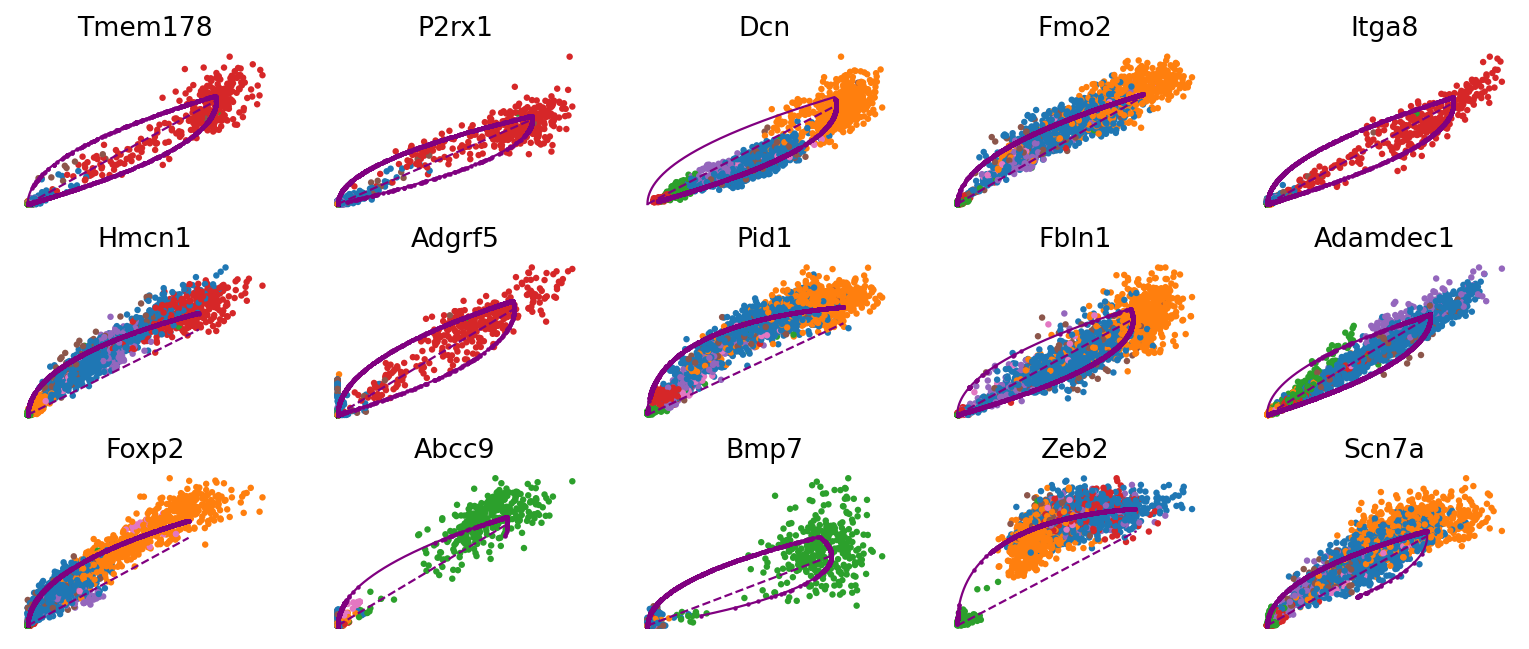

In [13]:
top_genes = adata.var['fit_likelihood'].sort_values(ascending=False).index
scv.pl.scatter(adata, basis=top_genes[:15], ncols=5, frameon=False)

In [14]:
# var_names = ['Actn4', 'Ppp3ca', 'Cpe', 'Nnat']
# scv.pl.scatter(adata, var_names, frameon=False)
# scv.pl.scatter(adata, x='latent_time', y=var_names, frameon=False)

### Cluster-specific top-likelihood genes

Moreover, partial gene likelihoods can be computed for a each cluster of cells to enable cluster-specific identification of potential drivers.

In [15]:
scv.tl.rank_dynamical_genes(adata, groupby='clusters')
df = scv.get_df(adata, 'rank_dynamical_genes/names')
df.head(30)

ranking genes by cluster-specific likelihoods
    finished (0:00:03) --> added 
    'rank_dynamical_genes', sorted scores by group ids (adata.uns)


/tmp/ipykernel_38080/3350918713.py:2: DeprecationWarning: `get_df` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please `AnnData::get_df` or Scanpy's `scanpy.get.obs_df` or `scanpy.get.var_df`.
  df = scv.get_df(adata, 'rank_dynamical_genes/names')
/home/xilab/software/miniconda-envs/bioinfo2/lib/python3.11/site-packages/scvelo/core/_anndata.py:257: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(data.obs[key])


,0,1,2,3,4,5,6
0,Dcn,Dcn,Il34,P2rx1,Scn7a,Dcn,Pcdh15
1,Fmo2,Fmo2,Hpse2,Tmem178,Hmcn1,Pid1,Rapgef5
2,Pid1,Tgfbr3,Ntn1,Adgrf5,Zeb2,Adamdec1,Mme
3,Fbln1,Fbln1,Ltbp1,Zeb2,Tnxb,Fmo2,Dcn
4,Scn7a,Pid1,Sv2b,Itga8,Irag1,Hmcn1,Fmo2
5,Hmcn1,Slit3,Bmp7,Col14a1,Pde3a,Ar,Csmd1
6,Svep1,Zeb2,Fblim1,Hmcn1,Hpse2,Scn7a,Stmn2
7,Fn1,Foxp2,Abcc9,Plpp3,Fermt2,Tgfbr3,Dsg2
8,Adamdec1,Il1r1,Alcam,Ncam1,Negr1,Svep1,Prkcb
9,Tnxb,Dkk2,Efnb2,Septin4,Man1a,Zeb2,Svep1


In [16]:
# for cluster in ['Ductal', 'Ngn3 high EP', 'Pre-endocrine', 'Beta']:
#     scv.pl.scatter(adata, df[cluster][:5], ylabel=cluster, frameon=False)